In [4]:
import pandas as pd
import unicodedata

# 1. Função de limpeza
def padronizar_municipio(nome):
    if pd.isna(nome): 
        return nome
    nome = str(nome).lower().strip()
    nome = ''.join(ch for ch in unicodedata.normalize('NFKD', nome) 
                   if not unicodedata.combining(ch))
    return nome

In [45]:
# 2. Carregando os dados (CORREÇÃO: populacao agora usa sep=';')
df_populacao = pd.read_csv('../data/raw/populacao_somente_es_2025.csv', sep=';') 
df_furtos = pd.read_csv('../data/raw/furtos_2025.csv', sep=';') 

# 3. Criando a chave padronizada (CORREÇÃO: usando os nomes exatos que o Pandas achou)
df_populacao['municipio_chave'] = df_populacao['NOME DO MUNICÍPIO'].apply(padronizar_municipio)
df_furtos['municipio_chave'] = df_furtos['MUNICÍPIO'].apply(padronizar_municipio)

# 4. Visualizando apenas as colunas de cidade para ver a mágica acontecer
print("Tabela de População:")
display(df_populacao[['NOME DO MUNICÍPIO', 'municipio_chave']].head())

print("\nTabela de Furtos:")
display(df_furtos[['MUNICÍPIO', 'municipio_chave']].head())

Tabela de População:


,NOME DO MUNICÍPIO,municipio_chave
0,Afonso Cláudio,afonso claudio
1,Águia Branca,aguia branca
2,Água Doce do Norte,agua doce do norte
3,Alegre,alegre
4,Alfredo Chaves,alfredo chaves



Tabela de Furtos:


,MUNICÍPIO,municipio_chave
0,CONCEICAO DA BARRA,conceicao da barra
1,ITAPEMIRIM,itapemirim
2,ARACRUZ,aracruz
3,VILA VELHA,vila velha
4,VILA VELHA,vila velha


In [44]:
# 1. Limpando os nomes das colunas de População (tirando espaços extras)
df_populacao.columns = df_populacao.columns.str.strip()

# 2. Agrupando e contando os furtos por cidade
df_furtos_agrupado = df_furtos.groupby('municipio_chave').size().reset_index(name='total_furtos')

# 3. Cruzando (Merge) as duas tabelas usando a nossa chave padronizada
# O how='left' garante que todas as 78 cidades da população continuem na tabela, mesmo se não tiverem furtos
df_iqv = pd.merge(df_populacao, df_furtos_agrupado, on='municipio_chave', how='left')

# Preenchendo com 0 as cidades que por acaso não tiveram nenhum furto registrado
df_iqv['total_furtos'] = df_iqv['total_furtos'].fillna(0)

# 4. Calculando a taxa de furtos por 100 mil habitantes
# (Garantindo que a população seja tratada como número antes de dividir)
df_iqv['POPULAÇÃO ESTIMADA'] = pd.to_numeric(df_iqv['POPULAÇÃO ESTIMADA'], errors='coerce')
df_iqv['taxa_furtos_100k'] = (df_iqv['total_furtos'] / df_iqv['POPULAÇÃO ESTIMADA']) * 100000

# 5. Organizando o DataFrame final e mostrando as cidades mais perigosas no topo
df_iqv_ordenado = df_iqv.sort_values(by='taxa_furtos_100k', ascending=False)

print("Ranking das cidades com maior taxa de furtos:")
display(df_iqv_ordenado[['NOME DO MUNICÍPIO', 'POPULAÇÃO ESTIMADA', 'total_furtos', 'taxa_furtos_100k']].head(10))

Ranking das cidades com maior taxa de furtos:


,NOME DO MUNICÍPIO,POPULAÇÃO ESTIMADA,total_furtos,taxa_furtos_100k
77,Vitória,343.38,2581,751649.79
44,Marataízes,45.95,242,526625.03
56,Piúma,23.91,118,493476.08
76,Vila Velha,506.78,2028,400174.44
16,Cariacica,376.20,1465,389420.52
66,São José do Calçado,11.41,42,368065.90
35,Itapemirim,44.02,138,313493.87
25,Fundão,18.90,57,301619.22
28,Guarapari,136.31,408,299315.54
69,Serra,579.72,1652,284965.16


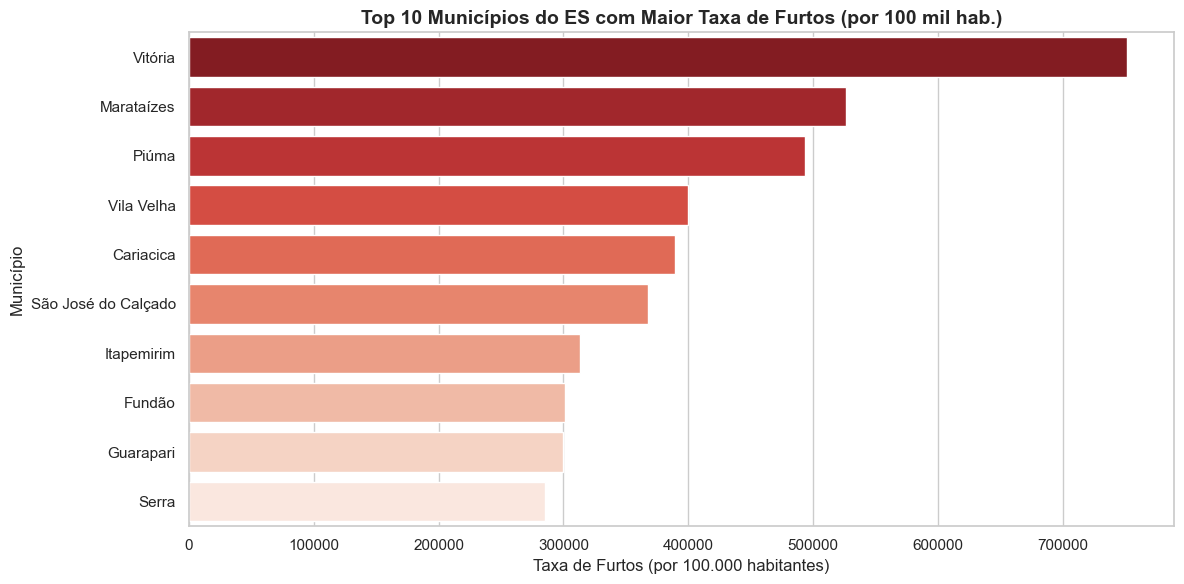

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Configurando o visual do gráfico para ficar profissional
sns.set_theme(style="whitegrid")

# 2. Pegando apenas as 10 primeiras cidades do ranking que você gerou
top10_furtos = df_iqv_ordenado.head(10)

# 3. Criando a figura e definindo o tamanho
plt.figure(figsize=(12, 6))

# 4. Criando o gráfico de barras horizontais
# Vamos usar uma paleta de cores avermelhada ('Reds_r') para dar a ideia de "alerta"
ax = sns.barplot(
    data=top10_furtos,
    x='taxa_furtos_100k',
    y='NOME DO MUNICÍPIO',
    palette='Reds_r',
    hue='NOME DO MUNICÍPIO', # O Seaborn pede o hue junto com palette agora
    legend=False
)

# 5. Adicionando títulos e rótulos
plt.title('Top 10 Municípios do ES com Maior Taxa de Furtos (por 100 mil hab.)', fontsize=14, fontweight='bold')
plt.xlabel('Taxa de Furtos (por 100.000 habitantes)', fontsize=12)
plt.ylabel('Município', fontsize=12)

# 6. Ajustando as margens e exibindo o gráfico
plt.tight_layout()
plt.show()

In [42]:
# 1. Carregando o arquivo de despesas financeiras primeiro!
df_despesas = pd.read_csv('../data/raw/municipios-despesas-2025.csv', sep=';', encoding='latin1')

# 2. Vamos descobrir como o governo nomeou as áreas de gasto (ex: Segurança, Saúde)
print("--- TOP 10 ÁREAS COM MAIS REGISTROS DE DESPESA ---")
display(df_despesas['DescricaoFuncao'].value_counts().head(10))

# 3. Vamos ver como o nome da cidade aparece na Unidade Gestora
print("\n--- EXEMPLOS DE UNIDADES GESTORAS ---")
display(df_despesas['UnidadeGestora'].drop_duplicates().head(10))

--- TOP 10 ÁREAS COM MAIS REGISTROS DE DESPESA ---


DescricaoFuncao
ADMINISTRAÇÃO         199631
SAÚDE                 193904
EDUCAÇÃO              172461
ASSISTÊNCIA SOCIAL    117819
URBANISMO              48435
LEGISLATIVA            31801
AGRICULTURA            27040
SANEAMENTO             20445
CULTURA                18887
DESPORTO E LAZER       18780
Name: count, dtype: int64


--- EXEMPLOS DE UNIDADES GESTORAS ---


0                            Prefeitura Municipal de Piúma
3819                             Câmara Municipal de Piúma
4231                     Fundo Municipal de Saúde de Piúma
10789         Serviço Autônomo de Água e Esgoto São Mateus
10804    Secretaria Municipal de Administração de São M...
11244                 Secretaria de Gabinete de São Mateus
11808        Secretaria Municipal de Governo de São Mateus
11920        Secretaria Municipal da Fazenda de São Mateus
12146                       Câmara Municipal de São Mateus
12807    Fundo Municipal de Assistência Social de São M...
Name: UnidadeGestora, dtype: object

In [41]:
# 1. Pegando a lista das 78 cidades capixabas que já padronizamos
cidades_es = df_populacao['municipio_chave'].dropna().unique()

# 2. Criando a função de "pesca"
def pescar_cidade(unidade_gestora):
    if pd.isna(unidade_gestora):
        return None
    
    # Limpamos a frase inteira (tira acentos e põe minúsculo) usando a função que já temos
    ug_limpa = padronizar_municipio(unidade_gestora)
    
    # Verificamos qual cidade do ES está escondida no texto
    for cidade in cidades_es:
        # Colocamos um espaço antes e depois para garantir que ache a palavra exata
        # Ex: evitar que ache "serra" dentro de "serrano"
        if f" {cidade} " in f" {ug_limpa} ": 
            return cidade
            
    return None

# 3. Aplicando a pesca na nossa base de finanças
df_despesas['municipio_chave'] = df_despesas['UnidadeGestora'].apply(pescar_cidade)

# 4. Preparando os valores financeiros (Trocando vírgula por ponto para o Python somar)
# Governos usam "1500,50", mas o Python de Ciência de Dados só entende "1500.50"
df_despesas['Paga'] = df_despesas['Paga'].astype(str).str.replace(',', '.').astype(float)

# 5. Filtrando SÓ os gastos com SAÚDE e somando tudo por município
df_gastos_saude = df_despesas[df_despesas['DescricaoFuncao'] == 'SAÚDE'].copy()
gastos_saude_agrupado = df_gastos_saude.groupby('municipio_chave')['Paga'].sum().reset_index(name='total_gasto_saude')

print("Gastos Totais com Saúde por Município:")
display(gastos_saude_agrupado.head(10))

Gastos Totais com Saúde por Município:


,municipio_chave,total_gasto_saude
0,afonso claudio,48118777.63
1,agua doce do norte,16052188.30
2,aguia branca,20897586.52
3,alegre,41142013.03
4,alfredo chaves,25965851.61
5,alto rio novo,12528936.66
6,anchieta,90617601.81
7,apiaca,17922143.37
8,aracruz,205069629.07
9,atilio vivacqua,26102348.53


In [22]:
# 1. Configurando o Pandas para mostrar números normais em vez de notação científica
pd.set_option('display.float_format', lambda x: '%.2f' % x)

# 2. Juntando a tabela de saúde na nossa tabela principal (df_iqv)
df_iqv = pd.merge(df_iqv, gastos_saude_agrupado, on='municipio_chave', how='left')

# Preenchendo com 0 caso alguma cidade não tenha gasto registrado
df_iqv['total_gasto_saude'] = df_iqv['total_gasto_saude'].fillna(0)

# 3. Calculando o Gasto per Capita (Total Gasto em Saúde / População)
df_iqv['gasto_saude_per_capita'] = df_iqv['total_gasto_saude'] / df_iqv['POPULAÇÃO ESTIMADA']

# 4. Ordenando para ver quem gasta MAIS por habitante
ranking_saude = df_iqv.sort_values(by='gasto_saude_per_capita', ascending=False)

print("Top 10 Municípios com Maior Gasto em Saúde por Habitante:")
display(ranking_saude[['NOME DO MUNICÍPIO', 'POPULAÇÃO ESTIMADA', 'total_gasto_saude', 'gasto_saude_per_capita']].head(10))

Top 10 Municípios com Maior Gasto em Saúde por Habitante:


,NOME DO MUNICÍPIO,POPULAÇÃO ESTIMADA,total_gasto_saude,gasto_saude_per_capita
58,Presidente Kennedy,14.85,69905512.69,4706808.02
39,Jerônimo Monteiro,12.11,39354781.33,3250312.30
6,Anchieta,33.02,90617601.81,2744574.06
49,Mucurici,5.65,15113723.66,2673575.74
57,Ponto Belo,6.67,16960070.91,2542358.10
35,Itapemirim,44.02,108404199.78,2462612.44
7,Apiacá,7.46,17922143.37,2401788.18
9,Atílio Vivácqua,11.05,26102348.53,2363058.89
18,Colatina,129.30,291246400.28,2252468.27
53,Pancas,19.12,39925566.50,2088157.24


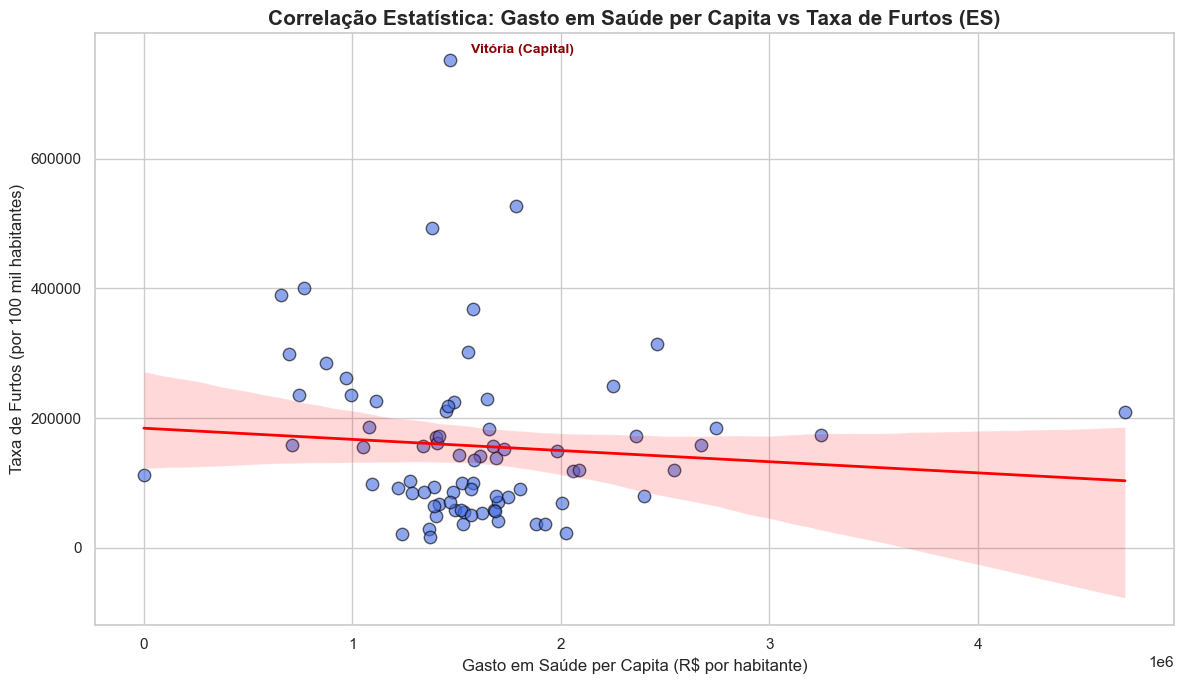

In [40]:
import pandas as pd
import unicodedata
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Função de padronização
def padronizar_municipio(nome):
    if pd.isna(nome): return nome
    nome = str(nome).lower().strip()
    return ''.join(ch for ch in unicodedata.normalize('NFKD', nome) if not unicodedata.combining(ch))

# 2. Carregando os dados brutos
df_populacao = pd.read_csv('../data/raw/populacao_somente_es_2025.csv', sep=';')
df_furtos = pd.read_csv('../data/raw/furtos_2025.csv', sep=';')
df_despesas = pd.read_csv('../data/raw/municipios-despesas-2025.csv', sep=';', encoding='latin1')

# 3. Limpeza dos nomes das colunas e das chaves (AQUI ESTAVA O ERRO!)
df_populacao.columns = df_populacao.columns.str.strip() # <- Essa linha tira os espaços invisíveis!

df_populacao['NOME DO MUNICÍPIO'] = df_populacao['NOME DO MUNICÍPIO'].str.strip()
df_populacao['municipio_chave'] = df_populacao['NOME DO MUNICÍPIO'].apply(padronizar_municipio)
df_furtos['municipio_chave'] = df_furtos['MUNICÍPIO'].apply(padronizar_municipio)

cidades_es = df_populacao['municipio_chave'].dropna().unique()

def pescar_cidade(ug):
    if pd.isna(ug): return None
    ug_limpa = padronizar_municipio(ug)
    for c in cidades_es:
        if f" {c} " in f" {ug_limpa} ": return c
    return None

df_despesas['municipio_chave'] = df_despesas['UnidadeGestora'].apply(pescar_cidade)
df_despesas['Paga'] = df_despesas['Paga'].astype(str).str.replace(',', '.').astype(float)

# 4. Agrupamentos
furtos_agrupado = df_furtos.groupby('municipio_chave').size().reset_index(name='total_furtos')
df_saude = df_despesas[df_despesas['DescricaoFuncao'] == 'SAÚDE']
saude_agrupado = df_saude.groupby('municipio_chave')['Paga'].sum().reset_index(name='total_gasto_saude')

# 5. Cruzamento das tabelas (Merge)
df_iqv = pd.merge(df_populacao, furtos_agrupado, on='municipio_chave', how='left')
df_iqv = pd.merge(df_iqv, saude_agrupado, on='municipio_chave', how='left')

# Preenchendo valores vazios e ajustando a população
df_iqv['total_furtos'] = df_iqv['total_furtos'].fillna(0)
df_iqv['total_gasto_saude'] = df_iqv['total_gasto_saude'].fillna(0)
df_iqv['POPULAÇÃO ESTIMADA'] = pd.to_numeric(df_iqv['POPULAÇÃO ESTIMADA'], errors='coerce')

# 6. Cálculos das Métricas Per Capita
df_iqv['taxa_furtos_100k'] = (df_iqv['total_furtos'] / df_iqv['POPULAÇÃO ESTIMADA']) * 100000
df_iqv['gasto_saude_per_capita'] = df_iqv['total_gasto_saude'] / df_iqv['POPULAÇÃO ESTIMADA']

# 7. Gerando o Gráfico de Dispersão
plt.figure(figsize=(12, 7))
sns.set_theme(style="whitegrid")

ax = sns.regplot(
    data=df_iqv,
    x='gasto_saude_per_capita',
    y='taxa_furtos_100k',
    scatter_kws={'s': 80, 'alpha': 0.6, 'color': 'royalblue', 'edgecolor': 'black'},
    line_kws={'color': 'red', 'linewidth': 2}
)

plt.title('Correlação Estatística: Gasto em Saúde per Capita vs Taxa de Furtos (ES)', fontsize=15, fontweight='bold')
plt.xlabel('Gasto em Saúde per Capita (R$ por habitante)', fontsize=12)
plt.ylabel('Taxa de Furtos (por 100 mil habitantes)', fontsize=12)

# Destacando Vitória
vitoria_dados = df_iqv[df_iqv['NOME DO MUNICÍPIO'] == 'Vitória']
if not vitoria_dados.empty:
    plt.annotate(
        'Vitória (Capital)', 
        xy=(vitoria_dados['gasto_saude_per_capita'].values[0], vitoria_dados['taxa_furtos_100k'].values[0]),
        xytext=(15, 5), textcoords='offset points',
        fontsize=10, fontweight='bold', color='darkred'
    )

plt.tight_layout()
plt.show()

🏆 RANKING FINAL - ÍNDICE DE QUALIDADE DE VIDA (IQV-ES)


C:\Users\imalp\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,NOME DO MUNICÍPIO,Nota_Saude,Nota_Seguranca,Nota_IQV_ES,Perfil_Municipio
58,Presidente Kennedy,100.00,73.93,86.96,Perfil B (Alerta/Ponto de Atenção)
39,Jerônimo Monteiro,69.06,78.73,73.89,Perfil B (Alerta/Ponto de Atenção)
7,Apiacá,51.03,91.40,71.21,Perfil B (Alerta/Ponto de Atenção)
64,São Domingos do Norte,42.99,99.34,71.17,Perfil C (Diferenciado/Alta Complexidade)
57,Ponto Belo,54.01,86.02,70.02,Perfil B (Alerta/Ponto de Atenção)
36,Itarana,40.93,97.39,69.16,Perfil C (Diferenciado/Alta Complexidade)
49,Mucurici,56.80,80.67,68.74,Perfil B (Alerta/Ponto de Atenção)
21,Divino de São Lourenço,39.92,97.30,68.61,Perfil C (Diferenciado/Alta Complexidade)
26,Governador Lindenberg,42.65,92.86,67.76,Perfil C (Diferenciado/Alta Complexidade)
6,Anchieta,58.31,77.19,67.75,Perfil B (Alerta/Ponto de Atenção)


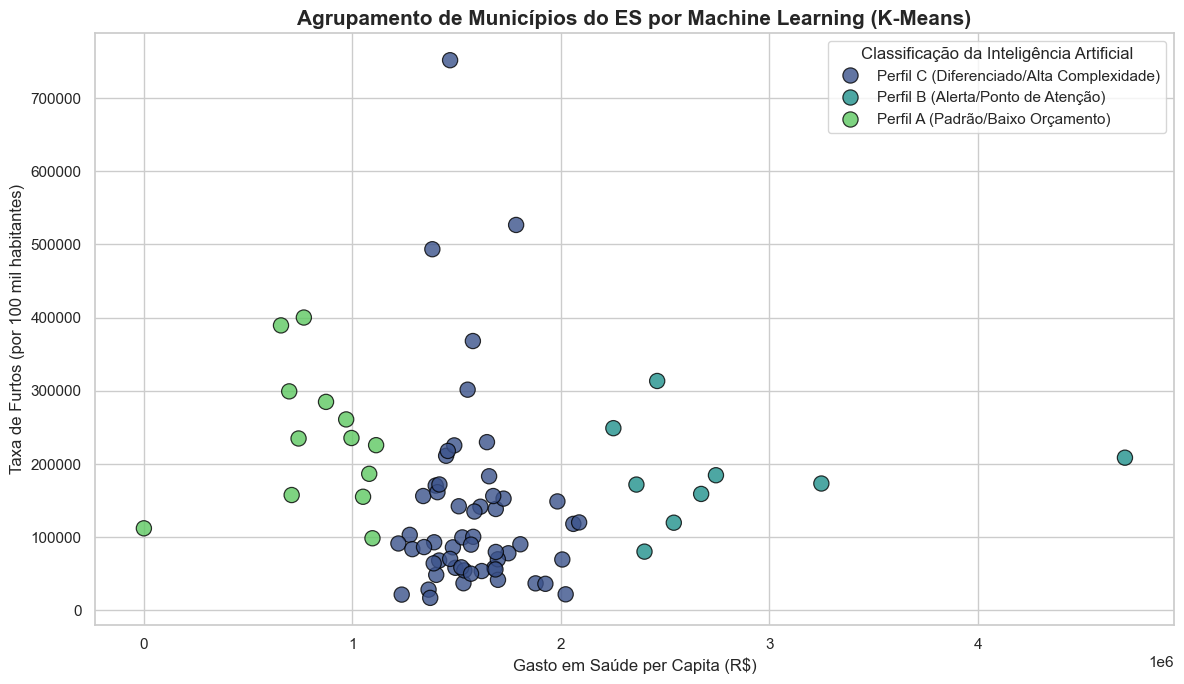

In [39]:
import pandas as pd
import unicodedata
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
import numpy as np


def padronizar_municipio(nome):
    if pd.isna(nome): return nome
    nome = str(nome).lower().strip()
    return ''.join(ch for ch in unicodedata.normalize('NFKD', nome) if not unicodedata.combining(ch))


df_populacao = pd.read_csv('../data/raw/populacao_somente_es_2025.csv', sep=';')
df_furtos = pd.read_csv('../data/raw/furtos_2025.csv', sep=';')
df_despesas = pd.read_csv('../data/raw/municipios-despesas-2025.csv', sep=';', encoding='latin1')


df_populacao.columns = df_populacao.columns.str.strip()
df_populacao['NOME DO MUNICÍPIO'] = df_populacao['NOME DO MUNICÍPIO'].str.strip()
df_populacao['municipio_chave'] = df_populacao['NOME DO MUNICÍPIO'].apply(padronizar_municipio)
df_furtos['municipio_chave'] = df_furtos['MUNICÍPIO'].apply(padronizar_municipio)

cidades_es = df_populacao['municipio_chave'].dropna().unique()

def pescar_cidade(ug):
    if pd.isna(ug): return None
    ug_limpa = padronizar_municipio(ug)
    for c in cidades_es:
        if f" {c} " in f" {ug_limpa} ": return c
    return None

df_despesas['municipio_chave'] = df_despesas['UnidadeGestora'].apply(pescar_cidade)
df_despesas['Paga'] = df_despesas['Paga'].astype(str).str.replace(',', '.').astype(float)

# Agrupamentos
furtos_agrupado = df_furtos.groupby('municipio_chave').size().reset_index(name='total_furtos')
df_saude = df_despesas[df_despesas['DescricaoFuncao'] == 'SAÚDE']
saude_agrupado = df_saude.groupby('municipio_chave')['Paga'].sum().reset_index(name='total_gasto_saude')

# Merge Final da Base
df_iqv = pd.merge(df_populacao, furtos_agrupado, on='municipio_chave', how='left')
df_iqv = pd.merge(df_iqv, saude_agrupado, on='municipio_chave', how='left')
df_iqv['total_furtos'] = df_iqv['total_furtos'].fillna(0)
df_iqv['total_gasto_saude'] = df_iqv['total_gasto_saude'].fillna(0)
df_iqv['POPULAÇÃO ESTIMADA'] = pd.to_numeric(df_iqv['POPULAÇÃO ESTIMADA'], errors='coerce')

# Taxas Per Capita
df_iqv['taxa_furtos_100k'] = (df_iqv['total_furtos'] / df_iqv['POPULAÇÃO ESTIMADA']) * 100000
df_iqv['gasto_saude_per_capita'] = df_iqv['total_gasto_saude'] / df_iqv['POPULAÇÃO ESTIMADA']


scaler = MinMaxScaler(feature_range=(0, 100))

# Notas Individuais
df_iqv['Nota_Saude'] = scaler.fit_transform(df_iqv[['gasto_saude_per_capita']])
taxa_furtos_norm = scaler.fit_transform(df_iqv[['taxa_furtos_100k']])
df_iqv['Nota_Seguranca'] = 100 - taxa_furtos_norm # Inverte porque furto é ruim

# Nota Final
df_iqv['Nota_IQV_ES'] = (df_iqv['Nota_Saude'] + df_iqv['Nota_Seguranca']) / 2

# Treinando Inteligência Artificial 
X = df_iqv[['gasto_saude_per_capita', 'taxa_furtos_100k']].fillna(0)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_iqv['Cluster_ML'] = kmeans.fit_predict(X)

def rotular_cluster(cluster_id):
    if cluster_id == 0: return 'Perfil A (Padrão/Baixo Orçamento)'
    elif cluster_id == 1: return 'Perfil B (Alerta/Ponto de Atenção)'
    else: return 'Perfil C (Diferenciado/Alta Complexidade)'

df_iqv['Perfil_Municipio'] = df_iqv['Cluster_ML'].apply(rotular_cluster)


ranking_final = df_iqv.sort_values(by='Nota_IQV_ES', ascending=False)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

print("🏆 RANKING FINAL - ÍNDICE DE QUALIDADE DE VIDA (IQV-ES)")
display(ranking_final[['NOME DO MUNICÍPIO', 'Nota_Saude', 'Nota_Seguranca', 'Nota_IQV_ES', 'Perfil_Municipio']].head(10))

# Gráfico
plt.figure(figsize=(12, 7))
sns.set_theme(style="whitegrid")

sns.scatterplot(
    data=df_iqv,
    x='gasto_saude_per_capita',
    y='taxa_furtos_100k',
    hue='Perfil_Municipio',
    palette='viridis',
    s=120,
    alpha=0.8,
    edgecolor='black'
)

plt.title('Agrupamento de Municípios do ES por Machine Learning (K-Means)', fontsize=15, fontweight='bold')
plt.xlabel('Gasto em Saúde per Capita (R$)', fontsize=12)
plt.ylabel('Taxa de Furtos (por 100 mil habitantes)', fontsize=12)
plt.legend(title='Classificação da Inteligência Artificial')

plt.tight_layout()
plt.show()

A descarregar a malha do ES...


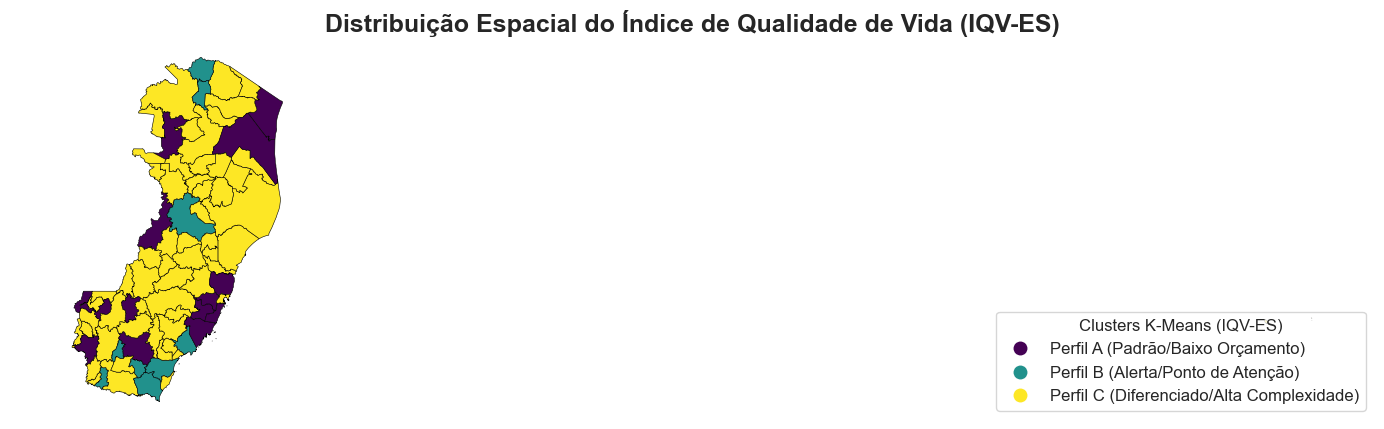

In [38]:
import geobr
import matplotlib.pyplot as plt
import geopandas as gpd
import unicodedata


print("A descarregar a malha do ES...")
es_map = geobr.read_municipality(code_muni="ES", year=2020)


def limpar_nome(nome):
    if pd.isna(nome): return nome
    nome = str(nome).lower().strip()
    return ''.join(ch for ch in unicodedata.normalize('NFKD', nome) if not unicodedata.combining(ch))

es_map['nome_limpo'] = es_map['name_muni'].apply(limpar_nome)

df_iqv['nome_limpo'] = df_iqv['NOME DO MUNICÍPIO'].apply(limpar_nome)

# 4. Fazer o merge dos mapas com os vossos resultados de Machine Learning
mapa_iqv = es_map.merge(df_iqv, on='nome_limpo', how='left')

# 5. Desenhar o Mapa Geográfico com impacto visual
fig, ax = plt.subplots(figsize=(14, 12)) 

# Pintar os municípios de acordo com o agrupamento do K-Means
mapa_iqv.plot(
    column='Perfil_Municipio', 
    cmap='viridis',            
    legend=True,
    legend_kwds={'title': "Clusters K-Means (IQV-ES)", 'loc': 'lower right', 'fontsize': 12},
    edgecolor='black',         
    linewidth=0.4,
    ax=ax,
    missing_kwds={'color': 'lightgrey', 'label': 'Sem dados'} 
)


ax.set_title('Distribuição Espacial do Índice de Qualidade de Vida (IQV-ES)', fontsize=18, fontweight='bold')
ax.axis('off')
# Mostrar o resultado
plt.tight_layout()
plt.show()

